# Standardized ConvoKit Corpora — Exploratory Data Analysis

#### See Appendix at end for reminders about dataset structure.

#### To run this yourself, make sure you download the standardized dataset (`standardized-v1-regenerated`) from Google Drive and place the folder in /data/local/ (you may have to create the local folder yourself)!

This notebook profiles the complete standardized Coarse Discourse and
Conversations Gone Awry–ChangeMyView (CGA-CMV) corpora for Task #3.

Goals:

1. Confirm that the local handoff matches its manifests.
2. Describe conversation size, depth, speakers, text, scores, and missingness.
3. Assess Coarse Discourse label balance.
4. Assess CGA-CMV outcomes, pairs, and provided splits.
5. Quantify structural repairs and define safe downstream modeling rules.

The notebook intentionally excludes raw text and speaker handles from its pandas
tables and outputs. That keeps the committed analysis aggregate-only and reduces
the chance of exposing identifiable source data.


# Summary

### Structure
* Coarse Discourse is broader (median 9 utterances, 6 speakers) but shallower (median depth 3); CGA-CMV is smaller (6 utterances, 3 speakers) but deeper (median depth 5)

### Missing Values
* Coarse Discourse has zero timestamps, 10.6% missing discourse labels, 5.1% missing scores
* CGA-CMV has complete timestamps/scores but zero discourse labels, titles, or URLs
* This rules out whole analyses per corpus (no time-based work on CD; no discourse-act work on CGA-CMV)
* Only 126 Coarse Discourse conversations were impacted by deleted utterances, with 188 synthetic placeholders added for 207 orphaned replies; don't include synthetic placeholders in training

### Imbalances
* Discourse label "answer" is 35.5% of utterances, while many other labels are \<5% -> considerable imbalance
* Labels "announcement" only appear at conversation roots; "answer," "agreement," "appreciation," "disagreement," "negativereaction" only appear in replies
* Community coverage is imbalanced (right-tailed), where r/askreddit and r/leagueoflegends dominate

### Text Features
* CGA-CMV messages run much longer than Coarse Discourse
* Scores are heavily skewed with extreme outliers in both corpora

### Modeling Implications
* Exclude synthetic placeholders from text training, but keep for structural analysis
* CGA-CMV already comes with splits and pairing, so preserve these from the standardized dataset
* Use class-aware metrics and weighting since discourse labels are imbalanced
* Treat the corpora as separate, task-specific datasets since they are not very comparable (each dataset has universally missing values)

## 0. Setup

Run this notebook from anywhere inside the repository. It finds the repository
root using `pyproject.toml` and prefers the regenerated UTF-8 handoff when both
local copies are present.


In [ ]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

current = Path.cwd().resolve()

REPO_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "pyproject.toml").exists()
)

ARTIFACTS_DIR = REPO_ROOT / "artifacts"
sys.path.insert(0, str(ARTIFACTS_DIR))

from standardize_convokit import iter_standardized

data_candidates = [
    REPO_ROOT / "data" / "local" / "standardized-v1-regenerated",
    REPO_ROOT / "data" / "local" / "standardized-v1",
]
DATA_DIR = next(path for path in data_candidates if path.exists())

CORPUS_FILES = {
    "Coarse Discourse": DATA_DIR / "reddit-coarse-discourse-corpus.jsonl",
    "CGA-CMV": DATA_DIR / "conversations-gone-awry-cmv-corpus.jsonl",
}

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.style.use("seaborn-v0_8-whitegrid")

print(f"Repository: {REPO_ROOT}")
print(f"Dataset:    {DATA_DIR}")


## 1. Validate the local handoff

Before analysis, verify that both JSONL files match the hashes recorded in their
manifests. The streaming loader will also validate schema and graph invariants as
each conversation is read.


In [2]:
def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


manifests = {}
for dataset, corpus_path in CORPUS_FILES.items():
    assert corpus_path.exists(), f"Missing dataset: {corpus_path}"
    manifest_path = corpus_path.with_suffix(".manifest.json")
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    actual_hash = sha256(corpus_path)
    expected_hash = manifest["output"]["sha256"]
    assert actual_hash == expected_hash, f"Checksum mismatch for {dataset}"
    manifests[dataset] = manifest
    print(f"{dataset}: checksum verified ({actual_hash[:12]}…)")


Coarse Discourse: checksum verified (2f2e8e9c74c5…)
CGA-CMV: checksum verified (ebd8bfd704f3…)


## 2. Build analysis tables

The source format stores one complete conversation per JSONL line. This cell
streams both files and creates:

- `conversations_df`: one row per conversation;
- `utterances_df`: one row per source or synthetic utterance;
- `real_utterances_df`: content-bearing source records only.

Raw text and speaker handles are deliberately not materialized.


In [ ]:
conversation_rows = []
utterance_rows = []

# the 2 datasets have the same structure, so we do the same operations for both
for dataset, corpus_path in CORPUS_FILES.items():

    # goes through JSONL files of the Coarse Discourse and CGA datasets line-by-line
    for conversation in iter_standardized(corpus_path):
        source_metadata = conversation.metadata["source_metadata"]

        # counts synthetic (placeholder) nodes
        synthetic_count = sum(
            bool(utterance.metadata.get("is_synthetic", False))
            for utterance in conversation.utterances
        )
        real_count = len(conversation.utterances) - synthetic_count

        # builds list of dicts for conversation df creation
        conversation_rows.append(
            {
                "dataset": dataset,
                "corpus": conversation.metadata["corpus"],
                "conversation_id": conversation.id,
                "source_id": conversation.source_id,
                "split": source_metadata.get("split"),
                "pair_id": source_metadata.get("pair_id"),
                "outcome": source_metadata.get("has_removed_comment"),
                "subreddit": source_metadata.get("subreddit"),
                "utterance_count": real_count,
                "output_utterance_count": len(conversation.utterances),
                "synthetic_count": synthetic_count,
                "speaker_count": len(conversation.speakers),
                "max_depth": max(u.depth for u in conversation.utterances),
                "has_synthetic_structure": bool(
                    conversation.metadata.get("has_synthetic_structure", False)
                ),
                "timestamp_missing": conversation.created_at is None,
                "title_missing": conversation.title is None,
                "url_missing": conversation.url is None,
            }
        )

        # goes through each utterance (comment) in the conversation
        for utterance in conversation.utterances:
            metadata = utterance.metadata
            source_depth = metadata.get("source_depth")
            is_synthetic = bool(metadata.get("is_synthetic", False))

            # builds list of dicts for utterance df creation
            utterance_rows.append(
                {
                    "dataset": dataset,
                    "corpus": conversation.metadata["corpus"],
                    "conversation_id": conversation.id,
                    "utterance_id": utterance.id,
                    "parent_id": utterance.parent_id,
                    "split": source_metadata.get("split"),
                    "outcome": source_metadata.get("has_removed_comment"),
                    "depth": utterance.depth,
                    "source_depth": source_depth,
                    "source_order": metadata.get("source_order"),
                    "discourse_act": utterance.discourse_act,
                    "score": utterance.score,
                    "is_root": utterance.parent_id is None,
                    "is_deleted": utterance.is_deleted,
                    "is_synthetic": is_synthetic,
                    "text_was_null": bool(metadata.get("text_was_null", False)),
                    "timestamp_missing": utterance.created_at is None,
                    "raw_empty": utterance.text == "",
                    "clean_empty": (utterance.text_clean or "") == "",
                    "raw_length": len(utterance.text),
                    "clean_length": len(utterance.text_clean or ""),
                    "cleaning_changed_text": utterance.text != utterance.text_clean,
                }
            )

conversations_df = pd.DataFrame(conversation_rows)
utterances_df = pd.DataFrame(utterance_rows)
real_utterances_df = utterances_df.loc[~utterances_df["is_synthetic"]].copy()

print(f"Conversation rows: {len(conversations_df):,}")
print(f"Utterance rows:    {len(utterances_df):,}")
print(f"Source rows:       {len(real_utterances_df):,}")


Conversation rows: 16,325
Utterance rows:    158,979
Source rows:       158,791


### Count reconciliation

These assertions compare the observed tables to the generated manifests. A
failure means the notebook should stop before producing EDA results.


In [ ]:
# integrity checks

count_rows = []

for dataset, manifest in manifests.items():
    expected = manifest["counts"]
    observed_conversations = conversations_df.loc[
        conversations_df["dataset"] == dataset
    ]
    observed_utterances = utterances_df.loc[utterances_df["dataset"] == dataset]

    row = {
        "dataset": dataset,
        "conversations": len(observed_conversations),
        "source_utterances": int((~observed_utterances["is_synthetic"]).sum()),
        "synthetic_utterances": int(observed_utterances["is_synthetic"].sum()),
        "rejected_conversations": expected["rejected_conversations"],
        "rejected_utterances": expected["rejected_utterances"],
    }

    assert row["conversations"] == expected["output_conversations"]
    assert row["source_utterances"] == expected["source_utterances"]
    assert row["synthetic_utterances"] == expected["synthetic_utterances"]
    assert row["rejected_conversations"] == 0
    assert row["rejected_utterances"] == 0
    count_rows.append(row)

count_summary = pd.DataFrame(count_rows).set_index("dataset")
count_summary


,conversations,source_utterances,synthetic_utterances,rejected_conversations,rejected_utterances
dataset,,,,,
Coarse Discourse,9483,115827,188,0,0
CGA-CMV,6842,42964,0,0,0


## 3. Conversation structure

Conversation size, depth, and speaker distributions describe the computational
shape of the data. The corpora are curated for different tasks, so they should
not be interpreted as interchangeable samples of Reddit.


In [ ]:
# shapes of the two datasets

structure_summary = conversations_df.groupby("dataset").agg(
    conversations=("conversation_id", "count"),
    total_utterances=("utterance_count", "sum"),
    median_utterances=("utterance_count", "median"),
    p95_utterances=("utterance_count", lambda x: x.quantile(0.95)),
    max_utterances=("utterance_count", "max"),
    median_speakers=("speaker_count", "median"),
    p95_speakers=("speaker_count", lambda x: x.quantile(0.95)),
    median_max_depth=("max_depth", "median"),
    p95_max_depth=("max_depth", lambda x: x.quantile(0.95)),
    max_depth=("max_depth", "max"),
)
structure_summary


,conversations,total_utterances,median_utterances,p95_utterances,max_utterances,median_speakers,p95_speakers,median_max_depth,p95_max_depth,max_depth
dataset,,,,,,,,,,
CGA-CMV,6842,42964,6.000,13.000,22,3.000,5.000,5.000,12.000,21
Coarse Discourse,9483,115827,9.000,38.000,41,6.000,22.000,3.000,8.000,10


Notes:
* Coarse discourse has median 9 utterances and 6 speakers, which are both greater than CGA-CMV's medians of 6 utterances and 3 speakers
* CGA-CMV's median max depth (5) is greater than Coarse Discourse's (3)
* \>95th percentiles for utterances and speakers in Coarse Discourse much higher than CGA-CMV's
* \>95th percentile for max depth in CGA-CMV is greater than in Coarse Discourse

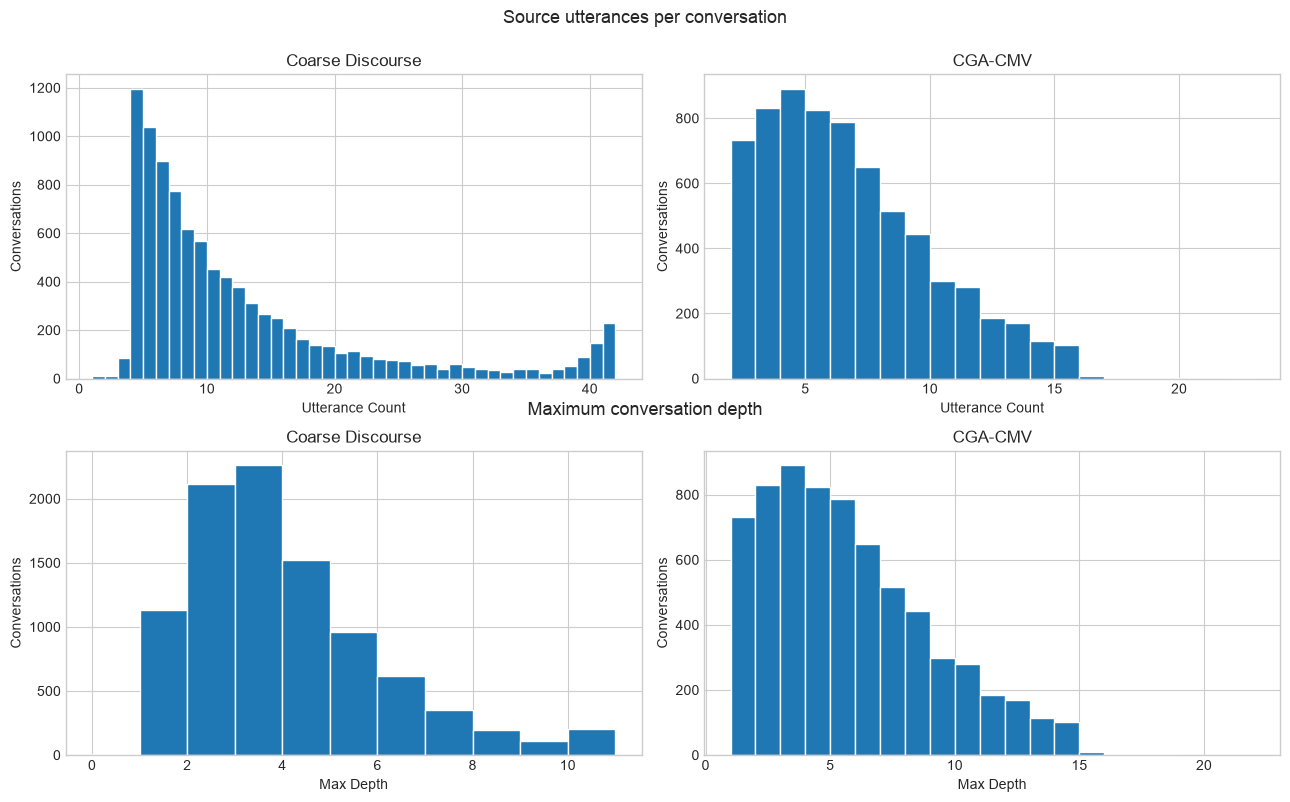

In [ ]:
# plot number of utterances per conversation and conversation depth
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for column, row, title in [
    ("utterance_count", 0, "Source utterances per conversation"),
    ("max_depth", 1, "Maximum conversation depth"),
]:
    for axis, dataset in zip(axes[row], CORPUS_FILES):
        values = conversations_df.loc[conversations_df["dataset"] == dataset, column]
        bins = range(int(values.min()), int(values.max()) + 2)
        axis.hist(values, bins=bins, edgecolor="white")
        axis.set_title(dataset)
        axis.set_xlabel(column.replace("_", " ").title())
        axis.set_ylabel("Conversations")
    fig.text(0.5, 0.98 if row == 0 else 0.49, title, ha="center", fontsize=13)

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


Notes:
* Coarse Discourse has more utterances and conversations than CGA-CMV
* Utterances and depths for both datasets are right-tailed
* Coarse Discourse has a wider range of utterance counts (max ~40) compared to CGA-CMV (max ~15)
* CGA-CMV has a wider range of max depths (max ~15) compared to Coarse Discourse (max ~10)

## 4. Missingness and content-quality indicators

Missing values are not interchangeable:

- Coarse Discourse has no source timestamps.
- CGA-CMV has no discourse-act labels.
- Null source text was converted to an empty string and flagged.
- Explicit `[deleted]` and `[removed]` markers remain source records.


In [ ]:
# missing values in utterances

quality_summary = real_utterances_df.groupby("dataset").agg(
    utterances=("utterance_id", "count"),
    missing_label_rate=("discourse_act", lambda x: x.isna().mean()),
    missing_score_rate=("score", lambda x: x.isna().mean()),
    missing_timestamp_rate=("timestamp_missing", "mean"),
    null_text_rate=("text_was_null", "mean"),
    raw_empty_rate=("raw_empty", "mean"),
    clean_empty_rate=("clean_empty", "mean"),
    deleted_marker_rate=("is_deleted", "mean"),
    cleaning_change_rate=("cleaning_changed_text", "mean"),
)
quality_summary


,utterances,missing_label_rate,missing_score_rate,missing_timestamp_rate,null_text_rate,raw_empty_rate,clean_empty_rate,deleted_marker_rate,cleaning_change_rate
dataset,,,,,,,,,
CGA-CMV,42964,1.000,0.000,0.000,0.000,0.000,0.000,0.028,0.627
Coarse Discourse,115827,0.106,0.051,1.000,0.011,0.022,0.022,0.009,0.364


Notes:
* CGA-CMV utterances completely lack labels, and Coarse Discourse utterances completely lack timestamps

In [ ]:
# missing values in conversations

conversation_missingness = conversations_df.groupby("dataset").agg(
    missing_conversation_timestamp_rate=("timestamp_missing", "mean"),
    missing_title_rate=("title_missing", "mean"),
    missing_url_rate=("url_missing", "mean"),
)
conversation_missingness


,missing_conversation_timestamp_rate,missing_title_rate,missing_url_rate
dataset,,,
CGA-CMV,0.000,1.000,1.000
Coarse Discourse,1.000,0.000,0.000


Notes:
* CGA-CMV conversations completely lack titles and URLs
* Coarse Discourse conversations completely lack conversation timestamps

## 5. Coarse Discourse labels

The majority discourse label is available in the canonical `discourse_act`
field. Missing labels remain null. The duplicate source field
`metadata.source_metadata.majority_type` must never be used as a predictor.


In [ ]:
# count discourse labels

coarse_utterances = real_utterances_df.loc[
    real_utterances_df["dataset"] == "Coarse Discourse"
].copy()

label_counts = (
    coarse_utterances["discourse_act"]
    .fillna("missing")
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
label_counts["percentage"] = label_counts["count"] / len(coarse_utterances) * 100
label_counts


,label,count,percentage
0,answer,41162,35.537
1,elaboration,19258,16.627
2,question,17594,15.190
3,missing,12277,10.599
4,appreciation,8710,7.520
5,agreement,5040,4.351
6,disagreement,3422,2.954
7,humor,2417,2.087
8,other,2049,1.769
9,announcement,2002,1.728


Notes:
* Labels are considerably imbalances, with 35% of all utterances being labelled as answers, and many other labels are \<5%

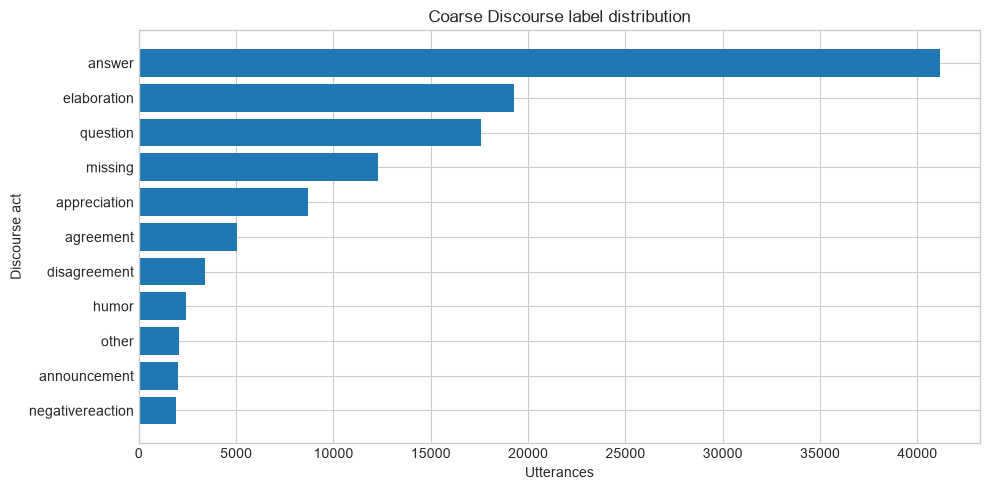

In [ ]:
# plot label frequencies

fig, axis = plt.subplots(figsize=(10, 5))
plot_data = label_counts.sort_values("count")
axis.barh(plot_data["label"], plot_data["count"])
axis.set_title("Coarse Discourse label distribution")
axis.set_xlabel("Utterances")
axis.set_ylabel("Discourse act")
plt.tight_layout()
plt.show()


In [ ]:
# group labels by their positions in the conversation

label_by_position = pd.crosstab(
    coarse_utterances["discourse_act"].fillna("missing"),
    coarse_utterances["is_root"].map({True: "root", False: "reply"}),
)
label_by_position


is_root,reply,root
discourse_act,,
agreement,5040,0
announcement,0,2002
answer,41162,0
appreciation,8710,0
disagreement,3422,0
elaboration,19258,0
humor,2355,62
missing,12054,223
negativereaction,1896,0


Notes:
* Announcements only appear in roots (first utterance in conversation)
* Agreements, answers, appreciations, disagreements, elaborations, and negative reactions only occur in replies

### Source-community coverage

The corpus covers many communities and is not a balanced subreddit sample.
Community frequencies should be considered when interpreting label patterns or
building cross-domain evaluations.


In [ ]:
# group by subreddit
coarse_conversations = conversations_df.loc[
    conversations_df["dataset"] == "Coarse Discourse"
]

top_subreddits = coarse_conversations["subreddit"].value_counts().head(20)
top_subreddits.to_frame("conversations")


,conversations
subreddit,
askreddit,425
leagueoflegends,244
buildapc,168
explainlikeimfive,96
trees,90
pcmasterrace,86
gaming,82
techsupport,76
electronic_cigarette,68


Notes:
* Distribution is right-tailed, where most conversations come from r/askreddit and r/leagueoflegends; many subreddits are represented by /<50 conversations

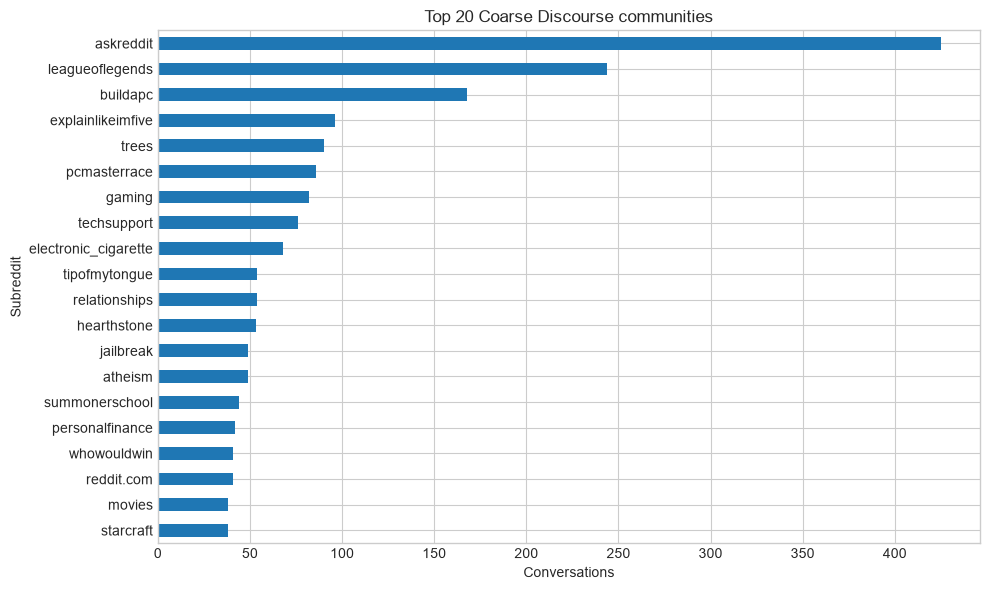

In [ ]:
# plot subreddit distribution
fig, axis = plt.subplots(figsize=(10, 6))
top_subreddits.sort_values().plot.barh(ax=axis)
axis.set_title("Top 20 Coarse Discourse communities")
axis.set_xlabel("Conversations")
axis.set_ylabel("Subreddit")
plt.tight_layout()
plt.show()


## 6. CGA-CMV outcomes, pairs, and splits

CGA-CMV is a matched-pair corpus. Each conversation points to its paired
conversation, the pair has opposite `has_removed_comment` outcomes, and both
members must stay in the provided split.


In [ ]:
# verify that the test / train / val split survived through standardization
cga_conversations = conversations_df.loc[
    conversations_df["dataset"] == "CGA-CMV"
].copy()

split_outcomes = pd.crosstab(
    cga_conversations["split"],
    cga_conversations["outcome"],
    margins=True,
)
split_outcomes


outcome,False,True,All
split,,,
test,684,684,1368
train,2053,2053,4106
val,684,684,1368
All,3421,3421,6842


In [ ]:
# link integrity check
cga_by_source = cga_conversations.set_index("source_id")
pair_checks = Counter()

for row in cga_conversations.itertuples():
    partner = cga_by_source.loc[row.pair_id]
    pair_checks["links"] += 1
    pair_checks["reciprocal_links"] += partner["pair_id"] == row.source_id
    pair_checks["same_split"] += partner["split"] == row.split
    pair_checks["opposite_outcome"] += partner["outcome"] != row.outcome

pair_summary = pd.Series(pair_checks, name="conversation_links").to_frame()
assert pair_checks["reciprocal_links"] == pair_checks["links"]
assert pair_checks["same_split"] == pair_checks["links"]
assert pair_checks["opposite_outcome"] == pair_checks["links"]
pair_summary


,conversation_links
links,6842
reciprocal_links,6842
same_split,6842
opposite_outcome,6842


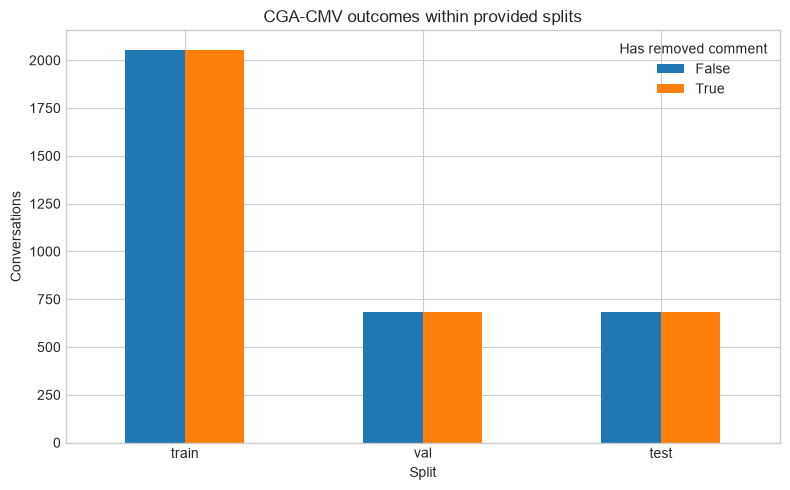

In [16]:
fig, axis = plt.subplots(figsize=(8, 5))
split_plot = pd.crosstab(cga_conversations["split"], cga_conversations["outcome"])
split_plot = split_plot.reindex(["train", "val", "test"])
split_plot.plot.bar(ax=axis)
axis.set_title("CGA-CMV outcomes within provided splits")
axis.set_xlabel("Split")
axis.set_ylabel("Conversations")
axis.legend(title="Has removed comment")
axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


Notes:
* Seems like nothing broke the links between conversations and utterances in CGA-CMV

## 7. Text length and voting scores

The plots clip their x-axes at each dataset's 99th percentile so a small number
of extreme values do not hide the main distribution. The summary tables still
report the full ranges.


In [17]:
text_summary = real_utterances_df.groupby("dataset")[[
    "raw_length", "clean_length"
]].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

score_summary = real_utterances_df.groupby("dataset")["score"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99]
)

text_summary


raw_length                                          \
                       count    mean     std   min     50%       90%   
dataset                                                                
CGA-CMV           42,964.000 578.594 778.726 1.000 337.000 1,303.700   
Coarse Discourse 115,827.000 243.359 442.131 0.000 121.000   544.000   

                                                clean_length                  \
                       95%       99%        max        count    mean     std   
dataset                                                                        
CGA-CMV          1,902.850 3,813.850 10,021.000   42,964.000 575.118 774.055   
Coarse Discourse   834.000 1,974.740 22,436.000  115,827.000 242.295 439.832   

                                                                         
                   min     50%       90%       95%       99%        max  
dataset                                                                  
CGA-CMV          1.000 335.000 1,296.000 1,896.850 3,791.850  9,992.000  
Coarse Discourse 0.000 121.000   543.000   830.000 1,965.740 22,107.000

In [18]:
score_summary


,count,mean,std,min,50%,90%,95%,99%,max
dataset,,,,,,,,,
CGA-CMV,"42,964.000",13.907,75.359,-740.000,2.000,21.000,50.000,261.000,"4,269.000"
Coarse Discourse,"109,973.000",5.952,54.670,-14.000,2.000,8.000,14.000,59.000,"6,470.000"


Notes:
* CGA-CMV on average has longer utterances than Coarse Discourse
* CGA-CMV has a much wider range of scores, but higher average score than Coarse Discourse

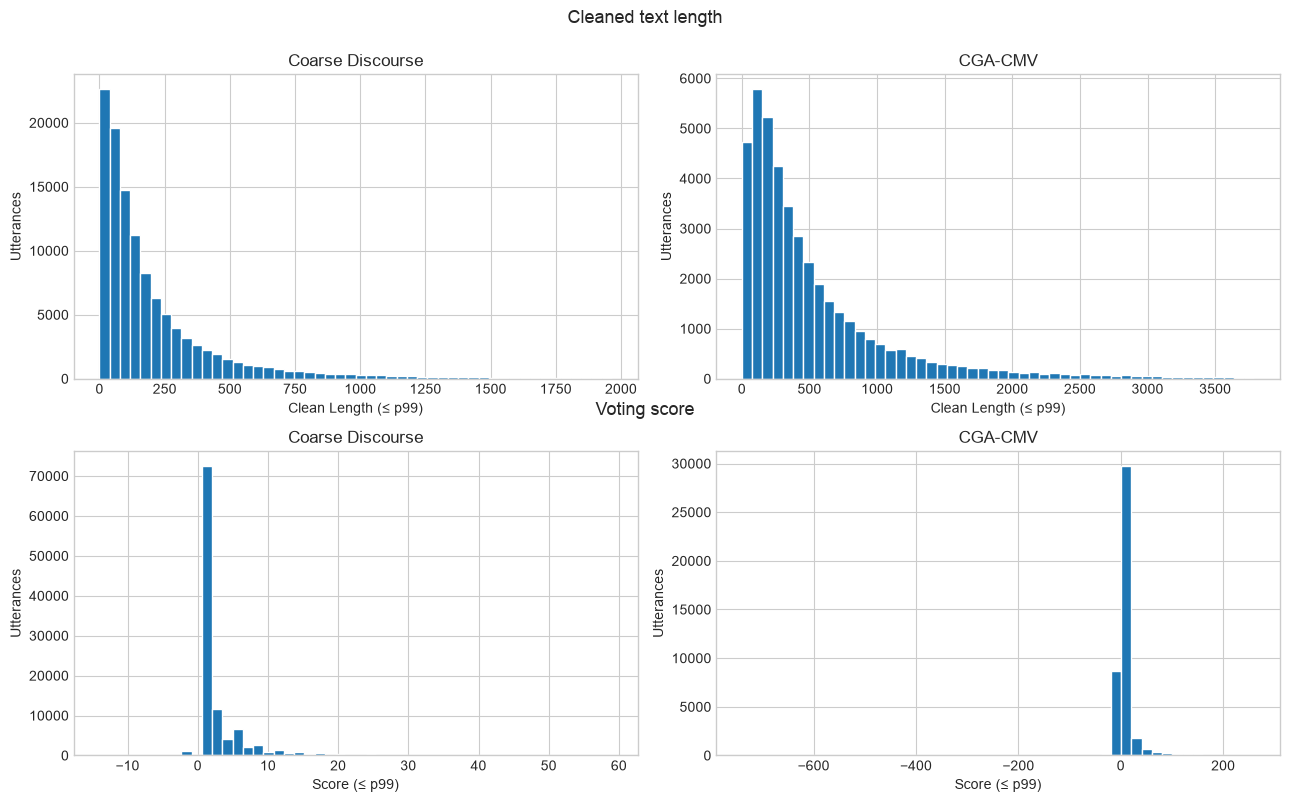

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for column, row, title in [
    ("clean_length", 0, "Cleaned text length"),
    ("score", 1, "Voting score"),
]:
    for axis, dataset in zip(axes[row], CORPUS_FILES):
        values = real_utterances_df.loc[
            real_utterances_df["dataset"] == dataset, column
        ].dropna()
        upper = values.quantile(0.99)
        clipped = values.loc[values <= upper]
        axis.hist(clipped, bins=50, edgecolor="white")
        axis.set_title(dataset)
        axis.set_xlabel(f"{column.replace('_', ' ').title()} (≤ p99)")
        axis.set_ylabel("Utterances")
    fig.text(0.5, 0.98 if row == 0 else 0.49, title, ha="center", fontsize=13)

fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


Notes:
* All distributions are unimodal, right tailed

## 8. Structural repairs

Missing Coarse Discourse parents are represented by synthetic placeholders.
They maintain traversability but are not recovered source content and must not be
treated as text examples.


In [ ]:
# count utterances and conversations affected by placeholders

repair_summary = conversations_df.groupby("dataset").agg(
    conversations=("conversation_id", "count"),
    repaired_conversations=("has_synthetic_structure", "sum"),
    synthetic_nodes=("synthetic_count", "sum"),
)
repair_summary["repaired_conversation_rate"] = (
    repair_summary["repaired_conversations"] / repair_summary["conversations"]
)

synthetic_ids = set(
    utterances_df.loc[utterances_df["is_synthetic"], "utterance_id"]
)
replies_to_placeholders = int(
    real_utterances_df["parent_id"].isin(synthetic_ids).sum()
)
source_depth_differences = int(
    (
        real_utterances_df["source_depth"].notna()
        & (real_utterances_df["source_depth"] != real_utterances_df["depth"])
    ).sum()
)

print(f"Replies attached to placeholders: {replies_to_placeholders:,}")
print(f"Source/recomputed depth differences: {source_depth_differences:,}")
repair_summary


Replies attached to placeholders: 207
Source/recomputed depth differences: 242


,conversations,repaired_conversations,synthetic_nodes,repaired_conversation_rate
dataset,,,,
CGA-CMV,6842,0,0,0.000
Coarse Discourse,9483,126,188,0.013


# Appendix
The standardized datasets have this structure, where each line is one conversation represented by one JSON object. This shape is shared across datasets (Coarse Discourse, CGA-CMV); the content of `title`/`url`, `created_at`, and the fields inside `metadata` differ by dataset.

Each JSON object (conversation) follows this structure:
```
{
  "id": "...",
  "source_id": "...",
  "source": "reddit",
  "schema_version": "...",
  "title": "...",           ← populated for Coarse Discourse; null for CGA-CMV
  "url": "...",             ← populated for Coarse Discourse; null for CGA-CMV
  "created_at": "...",      ← always null for Coarse Discourse; always populated for CGA-CMV
  "utterances": [ {…}, {…}, {…} ],  ← array of nested objects, not separate lines
  "speakers": { "speaker_id": {…} },  ← nested dict; real IDs are corpus-wide unique
  "metadata": { … }          ← contents differ per dataset (see source_metadata)
}
```